<a href="https://colab.research.google.com/github/VrishankDesai/Ai-in-healthcare/blob/main/ED_Discharge_Status_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

In [3]:
# ─────────────────────────────────────────
# 1. UPLOAD FILES
# ─────────────────────────────────────────
from google.colab import files
import io

print("Upload ED_metadata.csv first:")
up1 = files.upload()

print("Now upload ED2013+(1):")
up2 = files.upload()

Upload ED_metadata.csv first:


Saving ED_metadata.csv to ED_metadata (1).csv
Now upload ED2013+(1):


Saving ED2013+(1) to ED2013+(1)


In [6]:
# ─────────────────────────────────────────
# 2. PARSE FIXED-WIDTH DATA USING METADATA
# ─────────────────────────────────────────
# The ED2013 file is fixed-width format (each column has a set character width)
# The metadata tells us the width of each column and its name

meta   = pd.read_csv(io.BytesIO(up1['ED_metadata (1).csv']))
widths = meta['width'].tolist()
names  = meta['column_name'].tolist()

df = pd.read_fwf(io.BytesIO(up2['ED2013+(1)']), widths=widths, names=names)
print(f"\nRaw dataset shape: {df.shape}")


Raw dataset shape: (24777, 579)


In [7]:
# ─────────────────────────────────────────
# 3. BUILD TARGET VARIABLE
# ─────────────────────────────────────────
# ADMIT column: -7 = not admitted (discharged), 1-5 = admitted, 6 = observation
def map_target(val):
    if val == -7:           return 0   # Discharged
    elif val in [1,2,3,4,5]: return 1  # Admitted
    elif val == 6:          return 2   # Observation
    else:                   return np.nan

df['DISCHARGE_STATUS'] = df['ADMIT'].apply(map_target)

In [8]:
# ─────────────────────────────────────────
# 4. SELECT FEATURES & CLEAN DATA
# ─────────────────────────────────────────
# These are triage-level features available when a patient first arrives
features = [
    'AGE',        # Patient age
    'SEX',        # 1=Male, 2=Female
    'TEMPF',      # Body temperature (F x10, e.g. 986 = 98.6F)
    'PULSE',      # Heart rate (beats/min)
    'BPSYS',      # Systolic blood pressure
    'BPDIAS',     # Diastolic blood pressure
    'POPCT',      # Oxygen saturation %
    'IMMEDR',     # Immediacy/triage level (1=immediate, 5=non-urgent)
    'PAINSCALE',  # Pain score (0-10)
    'WAITTIME',   # Wait time before seen (minutes)
    'TOTCHRON',   # Total chronic conditions
    'ARREMS',     # Arrived by ambulance (1=yes, 2=no)
    'INJURY',     # Injury-related visit
    'DIABETES',   # Has diabetes
    'CANCER',     # Has cancer
    'CHF',        # Congestive heart failure
    'COPD',       # Chronic lung disease
    'NOCHRON',    # No chronic conditions
]

sub = df[features].copy()
sub['DISCHARGE_STATUS'] = df['DISCHARGE_STATUS']
sub = sub.dropna(subset=['DISCHARGE_STATUS'])

# Replace sentinel/missing codes with NaN
sentinel = [-9, -8, -7, 998, 999, 9999]
for col in features:
    sub[col] = sub[col].apply(lambda x: np.nan if x in sentinel else x)

sub = sub.dropna().reset_index(drop=True)
print(f"Clean dataset shape: {sub.shape}")
print("\nDischarge Status Distribution:")
print(sub['DISCHARGE_STATUS'].value_counts().rename({0:'Discharged',1:'Admitted',2:'Observation'}))

Clean dataset shape: (10505, 19)

Discharge Status Distribution:
DISCHARGE_STATUS
Discharged     9487
Observation     732
Admitted        286
Name: count, dtype: int64


/tmp/ipykernel_663/1299782744.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sub, x='STATUS_LABEL',


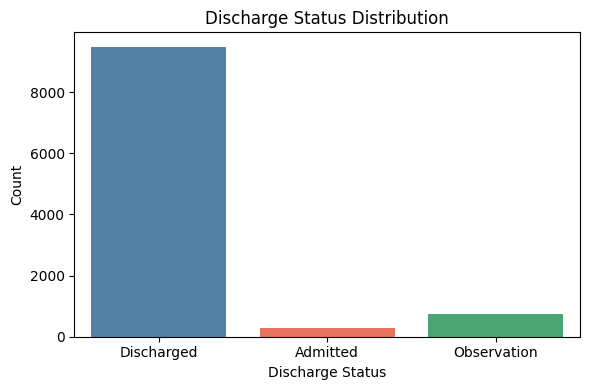

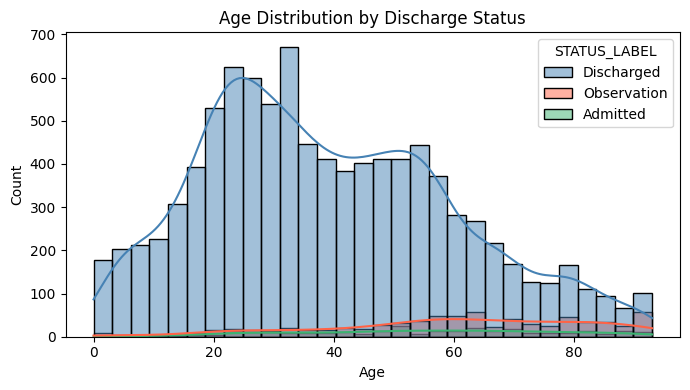

/tmp/ipykernel_663/1299782744.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='STATUS_LABEL', y='PAINSCALE',


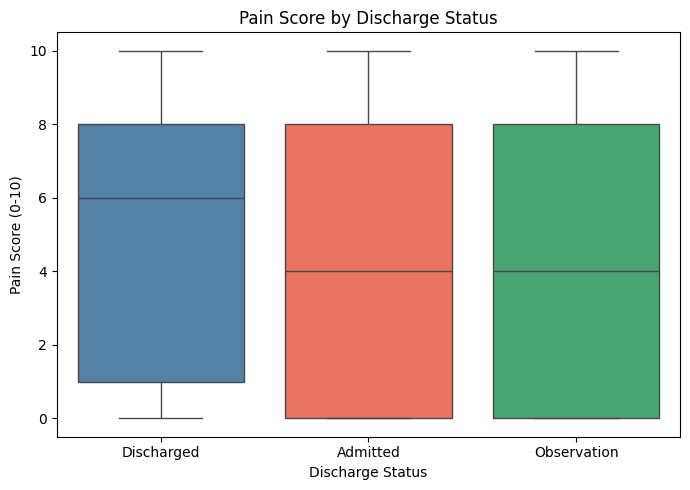

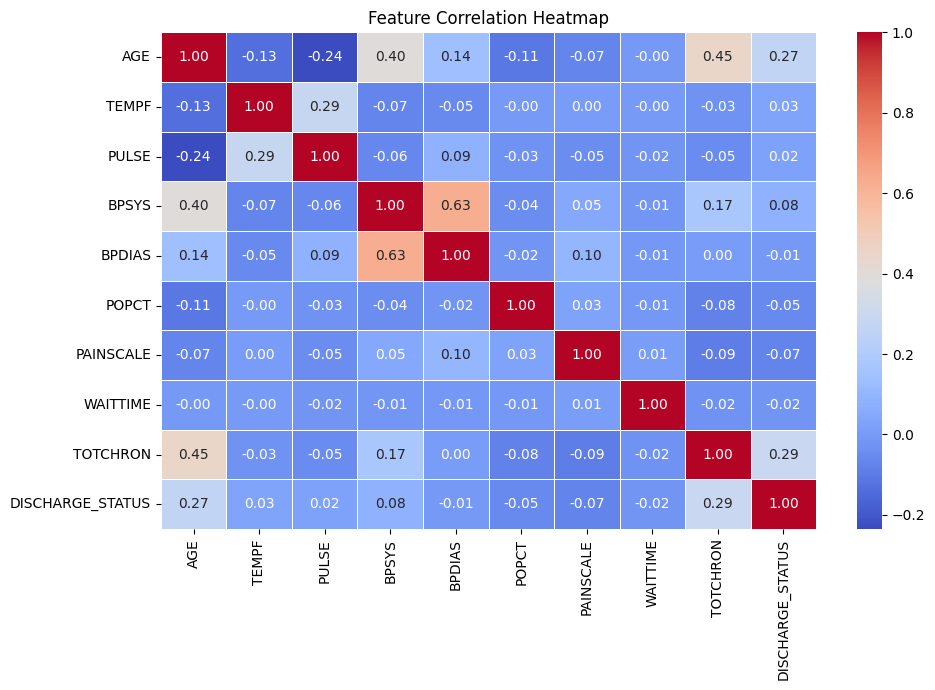

In [9]:
# ─────────────────────────────────────────
# 5. SEABORN PLOTS
# ─────────────────────────────────────────

label_map = {0: 'Discharged', 1: 'Admitted', 2: 'Observation'}
sub['STATUS_LABEL'] = sub['DISCHARGE_STATUS'].map(label_map)

# Plot 1: Discharge Status Count
plt.figure(figsize=(6, 4))
sns.countplot(data=sub, x='STATUS_LABEL',
              palette=['steelblue','tomato','mediumseagreen'],
              order=['Discharged','Admitted','Observation'])
plt.title("Discharge Status Distribution")
plt.xlabel("Discharge Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot 2: Age distribution by discharge status
plt.figure(figsize=(7, 4))
sns.histplot(data=sub, x='AGE', hue='STATUS_LABEL', kde=True, bins=30,
             palette=['steelblue','tomato','mediumseagreen'])
plt.title("Age Distribution by Discharge Status")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

# Plot 3: Pain Score vs Triage Level (colored by outcome)
plt.figure(figsize=(7, 5))
sns.boxplot(data=sub, x='STATUS_LABEL', y='PAINSCALE',
            palette=['steelblue','tomato','mediumseagreen'],
            order=['Discharged','Admitted','Observation'])
plt.title("Pain Score by Discharge Status")
plt.xlabel("Discharge Status")
plt.ylabel("Pain Score (0-10)")
plt.tight_layout()
plt.show()

# Plot 4: Correlation heatmap of key numeric features
plt.figure(figsize=(10, 7))
numeric_cols = ['AGE','TEMPF','PULSE','BPSYS','BPDIAS','POPCT',
                'PAINSCALE','WAITTIME','TOTCHRON','DISCHARGE_STATUS']
sns.heatmap(sub[numeric_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────
# 6. PREPROCESSING
# ─────────────────────────────────────────
X = sub[features].values
y = sub['DISCHARGE_STATUS'].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 8404 | Test: 2101


In [11]:
# ─────────────────────────────────────────
# 7. DEFINE ALL MODELS
# ─────────────────────────────────────────
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "SVM (RBF)"           : SVC(kernel='rbf', random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN"                 : KNeighborsClassifier(n_neighbors=5),
    "AdaBoost"            : AdaBoostClassifier(n_estimators=50, random_state=42),
    "MLP Classifier"      : MLPClassifier(hidden_layer_sizes=(64, 32),
                                          max_iter=500, random_state=42),
}

In [12]:
# ─────────────────────────────────────────
# 8. TRAIN AND EVALUATE ALL MODELS
# ─────────────────────────────────────────
results = {}
target_names = ['Discharged', 'Admitted', 'Observation']

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n── {name} (Accuracy: {accuracy:.2f}) ──")
    print(classification_report(y_test, y_pred, target_names=target_names))


── Logistic Regression (Accuracy: 0.91) ──
              precision    recall  f1-score   support

  Discharged       0.91      1.00      0.95      1897
    Admitted       0.00      0.00      0.00        57
 Observation       0.65      0.10      0.18       147

    accuracy                           0.91      2101
   macro avg       0.52      0.37      0.38      2101
weighted avg       0.87      0.91      0.87      2101



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



── Decision Tree (Accuracy: 0.83) ──
              precision    recall  f1-score   support

  Discharged       0.92      0.90      0.91      1897
    Admitted       0.07      0.09      0.08        57
 Observation       0.20      0.22      0.21       147

    accuracy                           0.83      2101
   macro avg       0.40      0.41      0.40      2101
weighted avg       0.85      0.83      0.84      2101


── SVM (RBF) (Accuracy: 0.90) ──
              precision    recall  f1-score   support

  Discharged       0.91      1.00      0.95      1897
    Admitted       0.00      0.00      0.00        57
 Observation       0.67      0.04      0.08       147

    accuracy                           0.90      2101
   macro avg       0.52      0.35      0.34      2101
weighted avg       0.86      0.90      0.86      2101



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



── Random Forest (Accuracy: 0.91) ──
              precision    recall  f1-score   support

  Discharged       0.91      1.00      0.95      1897
    Admitted       0.00      0.00      0.00        57
 Observation       0.58      0.07      0.13       147

    accuracy                           0.91      2101
   macro avg       0.50      0.36      0.36      2101
weighted avg       0.86      0.91      0.87      2101


── KNN (Accuracy: 0.90) ──
              precision    recall  f1-score   support

  Discharged       0.91      0.99      0.95      1897
    Admitted       0.00      0.00      0.00        57
 Observation       0.38      0.09      0.14       147

    accuracy                           0.90      2101
   macro avg       0.43      0.36      0.36      2101
weighted avg       0.85      0.90      0.87      2101



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



── AdaBoost (Accuracy: 0.90) ──
              precision    recall  f1-score   support

  Discharged       0.90      1.00      0.95      1897
    Admitted       0.00      0.00      0.00        57
 Observation       0.75      0.02      0.04       147

    accuracy                           0.90      2101
   macro avg       0.55      0.34      0.33      2101
weighted avg       0.87      0.90      0.86      2101



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



── MLP Classifier (Accuracy: 0.87) ──
              precision    recall  f1-score   support

  Discharged       0.92      0.94      0.93      1897
    Admitted       0.14      0.11      0.12        57
 Observation       0.22      0.19      0.21       147

    accuracy                           0.87      2101
   macro avg       0.43      0.41      0.42      2101
weighted avg       0.85      0.87      0.86      2101



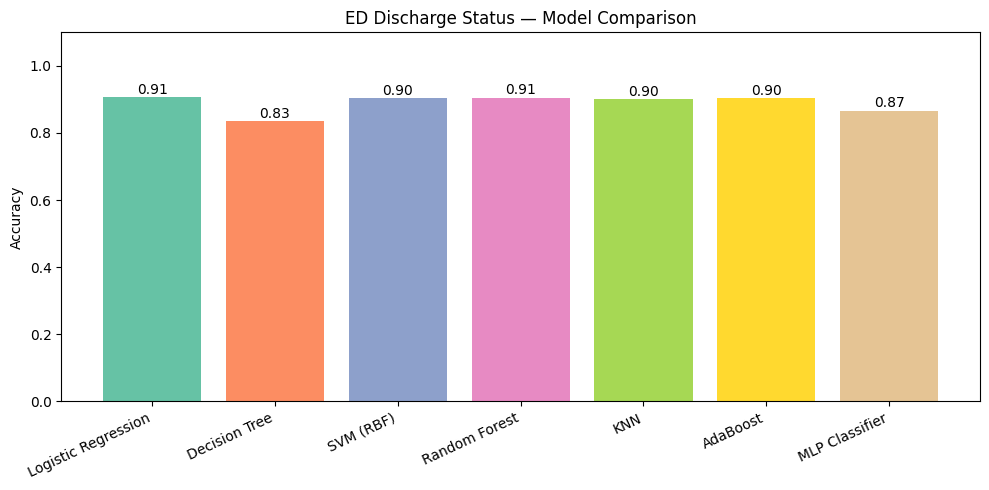

In [13]:
# ─────────────────────────────────────────
# 9. MODEL COMPARISON BAR CHART
# ─────────────────────────────────────────
plt.figure(figsize=(10, 5))
bars = plt.bar(results.keys(), results.values(),
               color=sns.color_palette("Set2", len(results)))
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("ED Discharge Status — Model Comparison")
plt.xticks(rotation=25, ha='right')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{val:.2f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

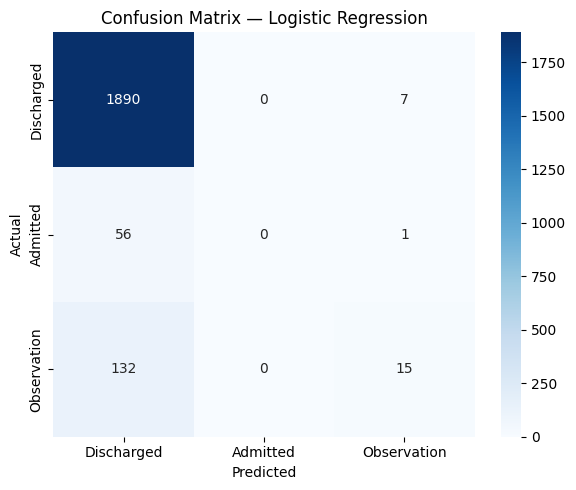


Best Model: Logistic Regression | Accuracy: 0.91


In [14]:
# ─────────────────────────────────────────
# 10. CONFUSION MATRIX FOR BEST MODEL
# ─────────────────────────────────────────
best_name  = max(results, key=results.get)
best_model = models[best_name]
y_best     = best_model.predict(X_test)
cm         = confusion_matrix(y_test, y_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"\nBest Model: {best_name} | Accuracy: {results[best_name]:.2f}")

/tmp/ipykernel_663/2791572327.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


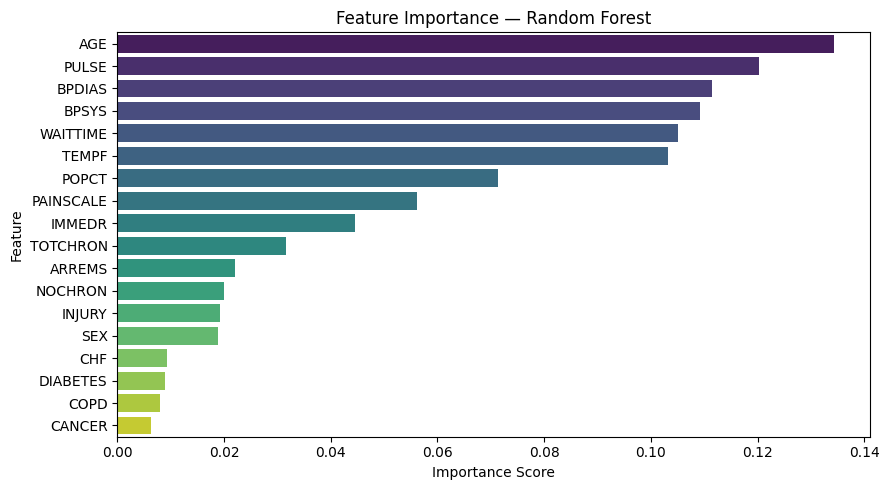

In [15]:
# ─────────────────────────────────────────
# 11. FEATURE IMPORTANCE (Random Forest)
# ─────────────────────────────────────────
rf_model    = models["Random Forest"]
importances = rf_model.feature_importances_
feat_df     = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df     = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()